# 0. Import

In [4]:
import os

os.chdir("../")

In [ ]:
import numpy as np
import torch
from glob import glob
import ast  
import matplotlib.pyplot as plt
import sys
import argparse
import warnings
import pickle
import pandas as pd
import json
from difflib import get_close_matches
import pickle as pkl
from glob import glob
from collections import defaultdict
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from torch_geometric.data import Data
from rdkit import Chem
from openbabel import openbabel as ob
from pymol import cmd
from plip.structure.preparation import PDBComplex
warnings.filterwarnings("ignore")
cmd.feedback("disable", "all", "everything")

handler = ob.OBMessageHandler()
handler.SetOutputLevel(0)
import sys
from utils import *

In [6]:
!pwd

/home/phuc.phamhuythienai@gmail.com/Desktop/LINKER


# 1. Data analysis

In [ ]:
data_name = "Davis"
with open(f"data/{data_name}/ligands.txt", "r", encoding="utf-8") as f:
    content = f.read()

ligands_dict = ast.literal_eval(content)

print(len(ligands_dict))
print(ligands_dict)

68
{'11314340': 'CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N', '24889392': 'CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C5=C(C=C(C=C5)OCCN6CCOCC6)SC4=N3', '11409972': 'CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3)OC4=NC=NC(=C4)NC)C(F)(F)F', '11338033': 'C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl', '10184653': 'CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C3)F)Cl)OC4CCOC4', '5287969': 'CN1CCC(C(C1)O)C2=C(C=C(C3=C2OC(=CC3=O)C4=CC=CC=C4Cl)O)O', '6450551': 'CNC(=O)C1=CC=CC=C1SC2=CC3=C(C=C2)C(=NN3)C=CC4=CC=CC=N4', '11364421': 'CCC1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=C(C=C4)C(=O)NC5CCN(CC5)C)OC)C', '9926054': 'CC1=CC2=C(C=C1)N=C(C3=NC=C(N23)C)NCCN.Cl', '16007391': 'CCN(CCCOC1=CC2=C(C=C1)C(=NC=N2)NC3=NNC(=C3)CC(=O)NC4=CC(=CC=C4)F)CCO', '5328940': 'CN1CCN(CC1)CCCOC2=C(C=C3C(=C2)N=CC(=C3NC4=CC(=C(C=C4Cl)Cl)OC)C#N)OC', '11234052': 'CC1=CC2=C(N1)C=CC(=C2F)OC3=NC=NN4C3=C(C(=C4)OCC(C)O)C', '11656518': 'CN1C2=C(C=C(C=C2)OC3=CC(=NC=C3)C4=NC=C(N4)C(F)(F)F)N=C1NC5=CC=C(C=C5)C(F)

In [ ]:
with open(f"data/{data_name}/proteins.txt", "r", encoding="utf-8") as f:
    content = f.read()

protein_dict = ast.literal_eval(content)

print(len(protein_dict))
print(protein_dict)

442
{'AAK1': 'MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIQIMRDLSGHKNIVGYIDSSINNVSSGDVWEVLILMDFCRGGQVVNLMNQRLQTGFTENEVLQIFCDTCEAVARLHQCKTPIIHRDLKVENILLHDRGHYVLCDFGSATNKFQNPQTEGVNAVEDEIKKYTTLSYRAPEMVNLYSGKIITTKADIWALGCLLYKLCYFTLPFGESQVAICDGNFTIPDNSRYSQDMHCLIRYMLEPDPDKRPDIYQVSYFSFKLLKKECPIPNVQNSPIPAKLPEPVKASEAAAKKTQPKARLTDPIPTTETSIAPRQRPKAGQTQPNPGILPIQPALTPRKRATVQPPPQAAGSSNQPGLLASVPQPKPQAPPSQPLPQTQAKQPQAPPTPQQTPSTQAQGLPAQAQATPQHQQQLFLKQQQQQQQPPPAQQQPAGTFYQQQQAQTQQFQAVHPATQKPAIAQFPVVSQGGSQQQLMQNFYQQQQQQQQQQQQQQLATALHQQQLMTQQAALQQKPTMAAGQQPQPQPAAAPQPAPAQEPAIQAPVRQQPKVQTTPPPAVQGQKVGSLTPPSSPKTQRAGHRRILSDVTHSAVFGVPASKSTQLLQAAAAEASLNKSKSATTTPSGSPRTSQQNVYNPSEGSTWNPFDDDNFSKLTAEELLNKDFAKLGEGKHPEKLGGSAESLIPGFQSTQGDAFATTSFSAGTAEKRKGGQTVDSGLPLLSVSDPFIPLQVPDAPEKLIEGLKSPDTSLLLPDLLPMTDPFGSTSDAVIEKADVAVESLIPGLEPPVPQRLPSQTESVTSNRTDSLTGEDSLLDCSLLSNPTTDLLEEFAPTAISAPVHKAAEDSNLISGFDVPEGSDKVAEDEFDPIPVLITKNPQGGHSRNSSGSSESSLPNLARSLLLVDQLIDL', 'ABL1(E255K)': 'PFWKIL

In [ ]:
with open(f"data/{data_name}/test_fold.txt", "r", encoding="utf-8") as f:
    content = f.read()

indices = ast.literal_eval(content)
print(len(indices))
print(indices)

5010
[9331, 10366, 13309, 9889, 26788, 28865, 19895, 25922, 8514, 10412, 27683, 10265, 5326, 25420, 19174, 27638, 20934, 9214, 11166, 26832, 21863, 6843, 7858, 14621, 26142, 25600, 13847, 5558, 2239, 23289, 4946, 12386, 26702, 17612, 17682, 29016, 14362, 23091, 28370, 10955, 26156, 12770, 25473, 27925, 30049, 12029, 3754, 17162, 13480, 16722, 13858, 16663, 23193, 15793, 23526, 21162, 12371, 4971, 29262, 15583, 20399, 17018, 2996, 27592, 5229, 18861, 26181, 9728, 8752, 5173, 19850, 18348, 15247, 3241, 2044, 25988, 30031, 29830, 10676, 23602, 6570, 12069, 18223, 1009, 25239, 19536, 6731, 1210, 17779, 23377, 16430, 6360, 1232, 24655, 20678, 14997, 26893, 22854, 1192, 20902, 27890, 12846, 24935, 27001, 27548, 2935, 4900, 2741, 12563, 15688, 8968, 22746, 25958, 21455, 6233, 1299, 12339, 9941, 17620, 28897, 14744, 19209, 5995, 4517, 28021, 4475, 27070, 2139, 8780, 19319, 12982, 9583, 3530, 5266, 2962, 6186, 6833, 24085, 6355, 25706, 6604, 20507, 22436, 21612, 16760, 18251, 26030, 12238, 1107

In [ ]:
with open(f"data/{data_name}/train_folds.txt", "r", encoding="utf-8") as f:
    content = f.read()
indices = ast.literal_eval(content)
for i in range(len(indices)):
    print(len(indices[i]))
    print(indices[i])

5010
[1483, 18097, 11736, 16204, 2085, 2144, 943, 18735, 10666, 2157, 12561, 20525, 19925, 7777, 20559, 21935, 4774, 10742, 5030, 9424, 21135, 7336, 3556, 16633, 29640, 15363, 24722, 29131, 27290, 16090, 7091, 9371, 6839, 7677, 14768, 23588, 15871, 28700, 20865, 24128, 26480, 7924, 5313, 5790, 15136, 2208, 29459, 27047, 24623, 19879, 6324, 21167, 14092, 23362, 22368, 3668, 28591, 169, 3462, 28424, 14003, 11748, 24049, 16819, 24465, 6376, 2859, 27101, 285, 24314, 8380, 20406, 26652, 5197, 1699, 11229, 11169, 13633, 10823, 3220, 29322, 12546, 10090, 10919, 25789, 11762, 8330, 27078, 24544, 7273, 26896, 20699, 1634, 12374, 10546, 15328, 1933, 21396, 26463, 20665, 26046, 9592, 14872, 18263, 17396, 1428, 7240, 9559, 17293, 21552, 12305, 18188, 27399, 15307, 11568, 29719, 2097, 16643, 13547, 29048, 20834, 11670, 21704, 27687, 7500, 853, 6761, 17021, 23649, 11626, 10076, 6657, 28469, 12689, 22106, 8709, 4431, 13590, 20231, 26840, 14887, 18818, 906, 29620, 28342, 20637, 25511, 29193, 15220, 18

In [ ]:
Y = pickle.load(open(f"data/{data_name}/Y", 'rb'))

In [ ]:
df = pd.read_csv(f"data/{data_name}/full.csv")

In [128]:
label = df['label']

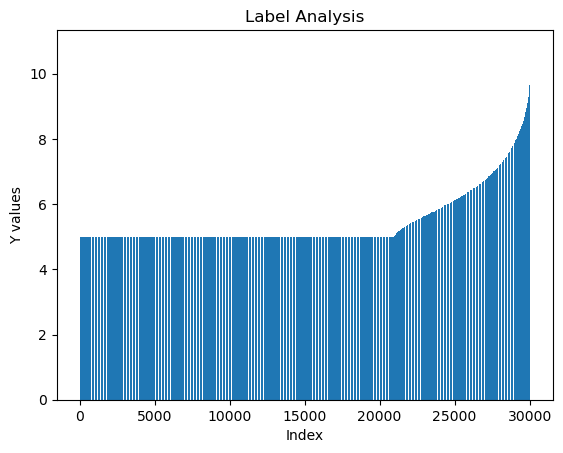

In [129]:
Y = sorted(label)
X = range(len(Y))
plt.bar(X, Y)
plt.xlabel('Index')
plt.ylabel('Y values')
plt.title('Label Analysis')
plt.show()

In [ ]:
df = pd.read_csv(f"data/{data_name}/full.csv")

In [ ]:
with open(f"data/{data_name}/train_folds.txt", "r", encoding="utf-8") as f:
    content = f.read()

train_indices = ast.literal_eval(content)
train_indices = [y for x in train_indices for y in x]
train_df = df.iloc[train_indices]
# print(train_df.head())
print(len(train_df))

25046


In [ ]:
test_df_drop = df.drop(train_indices)
print("Train size:", len(train_df))
print("Test size:", len(test_df_drop))

Train size: 25046
Test size: 5010


In [ ]:
with open(f"data/{data_name}/test_fold.txt", "r", encoding="utf-8") as f:
    content = f.read()

test_indices = ast.literal_eval(content)
test_df_indices = df.iloc[test_indices]
print("Train size:", len(train_df))
print("Test size:", len(test_df_drop))

Train size: 25046
Test size: 5010


In [143]:
test_df_drop = test_df_drop.sort_index(ascending=True)
test_df_drop

,ligand,protein,label
19,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ACVR2A,5.000000
21,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ACVRL1,5.000000
27,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ALK,5.000000
47,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,BRSK1,5.000000
51,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,CAMK1D,5.619789
...,...,...,...
30026,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TLK2,5.000000
30027,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TNIK,5.000000
30031,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TRKA,5.000000
30049,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,YANK2,5.000000


In [144]:
test_df_indices = test_df_indices.sort_index(ascending=True)
test_df_indices

,ligand,protein,label
19,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ACVR2A,5.000000
21,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ACVRL1,5.000000
27,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ALK,5.000000
47,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,BRSK1,5.000000
51,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,CAMK1D,5.619789
...,...,...,...
30026,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TLK2,5.000000
30027,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TNIK,5.000000
30031,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TRKA,5.000000
30049,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,YANK2,5.000000


In [145]:
test_df_drop.equals(test_df_indices)

True

In [ ]:
data_name = "KIBA"
with open(f"data/{data_name}/ligands.txt", "r", encoding="utf-8") as f:
    content = f.read()

print(content)

{"CHEMBL1087421": "COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl", "CHEMBL1088633": "COC1=C(C=C2C(=C1)CCN=C2C3=CC(=CC=C3)Cl)Cl", "CHEMBL1090360": "C1COCCN1C2=CC(=CC=C2)NC3=NC=CC(=N3)C4=C(N=C5N4C=CS5)C6=CC(=CC=C6)NC(=O)CC7=CC=CC=C7", "CHEMBL1688215": "C1=CC2=C(C=C1C3=NC(=NC=C3)N)NN=C2N", "CHEMBL1765781": "CNC1=NC(=CN=C1)C2=CNC(=O)C(=C2)NC(=O)C3=CC=C(C=C3)N4CCCC4CN5CCCC5", "CHEMBL1788116": "C1=CC=C2C(=C1)NC(=C(C#N)C3=NC(=NC=C3)NCCC4=CN=CC=C4)S2.C(=O)(C(F)(F)F)O.C(=O)(C(F)(F)F)O", "CHEMBL1929238": "CC(C)(C)C1=CC(=C(S1)NC(=O)NC2=C(C(=CC=C2)Cl)Cl)C(=O)N3CCC(=O)N(CC3)CCN(C)C", "CHEMBL1933552": "CC1CCC(CN1)N2CCC3(C2)CN(C4=CC=CC=C34)C(=O)C5=CC6=C(N5)C=C(C=C6)F", "CHEMBL202930": "COC1=C(C=CC(=C1)C2=CC3=C(C=C2)C(=CC4=CC=CN4)C(=O)N3)O", "CHEMBL204420": "CN1CCN(C(C1)C(=O)N)CC2=C(C=C3C(=C2)C(=NC=N3)NC4=C(C(=CC=C4)Cl)F)OC", "CHEMBL206783": "COC1=C(C=C2C(=C1)N=CN=C2NC3=C(C(=CC=C3)Cl)F)CN4CCCCC4C(=O)N", "CHEMBL206955": "COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)CN4CCCC4C(=O)N", "CHEMBL207037": "COC1

In [ ]:
with open(f"data/{data_name}/proteins.txt", "r", encoding="utf-8") as f:
    content = f.read()

print(content)

{"O00141": "MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNSYACKHPEVQSILKISQPQEPELMNANPSPPPSPSQQINLGPSSNPHAKPSDFHFLKVIGKGSFGKVLLARHKAEEVFYAVKVLQKKAILKKKEEKHIMSERNVLLKNVKHPFLVGLHFSFQTADKLYFVLDYINGGELFYHLQRERCFLEPRARFYAAEIASALGYLHSLNIVYRDLKPENILLDSQGHIVLTDFGLCKENIEHNSTTSTFCGTPEYLAPEVLHKQPYDRTVDWWCLGAVLYEMLYGLPPFYSRNTAEMYDNILNKPLQLKPNITNSARHLLEGLLQKDRTKRLGAKDDFMEIKSHVFFSLINWDDLINKKITPPFNPNVSGPNDLRHFDPEFTEEPVPNSIGKSPDSVLVTASVKEAAEAFLGFSYAPPTDSFL", "O00311": "MEASLGIQMDEPMAFSPQRDRFQAEGSLKKNEQNFKLAGVKKDIEKLYEAVPQLSNVFKIEDKIGEGTFSSVYLATAQLQVGPEEKIALKHLIPTSHPIRIAAELQCLTVAGGQDNVMGVKYCFRKNDHVVIAMPYLEHESFLDILNSLSFQEVREYMLNLFKALKRIHQFGIVHRDVKPSNFLYNRRLKKYALVDFGLAQGTHDTKIELLKFVQSEAQQERCSQNKSHIITGNKIPLSGPVPKELDQQSTTKASVKRPYTNAQIQIKQGKDGKEGSVGLSVQRSVFGERNFNIHSSISHESPAVKLMKQSKTVDVLSRKLATKKKAISTKVMNSAVMRKTASSCPASLTCDCYATDKVCSICLSRRQQVAPRAGTPGFRAPEVLTKCPNQTTAIDMWSAGVIFLSLLSGRYPFYKASDDLTALAQIMTIRGSRETIQAAKTFGKSILCSKEVPAQDLRKLCERLRGMDSSTPKLTSDIQGHASHQPAISEKTDHKASCLVQTPPGQYSGNSFKKGDSNSCEHCFDEYNTNLEGWNEVPDEAY

In [ ]:
with open(f"data/{data_name}/test_fold.txt", "r", encoding="utf-8") as f:
    content = f.read()

indices = ast.literal_eval(content)
print(len(indices))
print(indices)

19709
[34121, 51548, 12611, 104850, 23744, 79716, 47565, 6166, 113707, 26852, 29930, 90721, 58109, 6584, 116921, 72612, 33040, 63084, 9595, 41607, 1650, 85508, 42953, 92045, 7557, 50256, 107446, 82850, 25675, 115238, 95496, 10839, 90105, 17418, 103243, 2203, 86803, 58159, 4200, 8470, 21685, 64587, 47022, 61855, 113381, 28541, 106070, 26100, 17644, 110274, 106863, 11202, 33386, 80485, 40528, 11595, 11830, 77648, 112147, 53447, 73972, 64323, 20563, 53029, 32980, 10339, 34021, 83207, 102212, 44323, 32492, 40687, 68375, 306, 10373, 110000, 111330, 58134, 5572, 84401, 111527, 112452, 63936, 10678, 80093, 118024, 117040, 103800, 54305, 85984, 83964, 101076, 96508, 103266, 31132, 76559, 99581, 25385, 107958, 65373, 35106, 50467, 81756, 77211, 75017, 109260, 110800, 5197, 79505, 24759, 26765, 25451, 66592, 29100, 2885, 31531, 94285, 49861, 115750, 79533, 39210, 30411, 36394, 68769, 111140, 115196, 21939, 49629, 79860, 6259, 118145, 3145, 93538, 71527, 2988, 46785, 11276, 108377, 48094, 9312, 2

In [ ]:
with open(f"data/{data_name}/train_folds.txt", "r", encoding="utf-8") as f:
    content = f.read()
indices = ast.literal_eval(content)
for i in range(len(indices)):
    print(len(indices[i]))
    print(indices[i])

19709
[113703, 51222, 98078, 29622, 80976, 112045, 13772, 30711, 60861, 37749, 81354, 63562, 95894, 4304, 66134, 113956, 101753, 52209, 77547, 4971, 97974, 85713, 81686, 99858, 51677, 51830, 86231, 45031, 33878, 45316, 72556, 112623, 71432, 11026, 117726, 39238, 73687, 106892, 112008, 59984, 20584, 32173, 6841, 74999, 95786, 23836, 62466, 45707, 51576, 72240, 117, 49544, 88312, 111398, 15103, 22355, 92143, 111880, 26589, 24839, 110747, 14799, 32230, 95217, 30087, 90408, 112689, 416, 93706, 76120, 47165, 12294, 14306, 68760, 3054, 68796, 8736, 51287, 13542, 69229, 97411, 67326, 41854, 108201, 99132, 69594, 81827, 70473, 3125, 2960, 47413, 6726, 113540, 3253, 40074, 2847, 88227, 108500, 91813, 97416, 31844, 52855, 77371, 103725, 50609, 78359, 48435, 47636, 42323, 107567, 99630, 34607, 88260, 34501, 48091, 87635, 110657, 72456, 82979, 56454, 100339, 56676, 89649, 587, 30117, 67957, 111577, 57844, 75278, 57147, 62471, 30098, 8515, 24842, 56295, 104700, 73539, 41633, 5039, 117756, 69040, 73

In [ ]:
df = pd.read_csv(f"data/{data_name}/full.csv")

In [158]:
label = df['label']

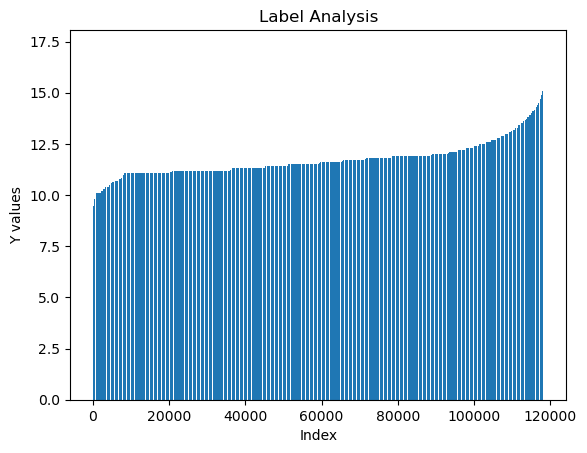

In [159]:
Y = sorted(label)
X = range(len(Y))
plt.bar(X, Y)
plt.xlabel('Index')
plt.ylabel('Y values')
plt.title('Label Analysis')
plt.show()

In [ ]:
df = pd.read_csv(f"data/{data_name}/full.csv")

In [ ]:
with open(f"data/{data_name}/train_folds.txt", "r", encoding="utf-8") as f:
    content = f.read()

train_indices = ast.literal_eval(content)
train_indices = [y for x in train_indices for y in x]
train_df = df.iloc[train_indices]
# print(train_df.head())
print(len(train_df))

98545


In [162]:
test_df_drop = df.drop(train_indices)
print("Train size:", len(train_df))
print("Test size:", len(test_df_drop))

Train size: 98545
Test size: 19709


In [ ]:
with open(f"data/{data_name}/test_fold.txt", "r", encoding="utf-8") as f:
    content = f.read()

test_indices = ast.literal_eval(content)
test_df_indices = df.iloc[test_indices]
print("Train size:", len(train_df))
print("Test size:", len(test_df_drop))

Train size: 98545
Test size: 19709


In [164]:
test_df_drop = test_df_drop.sort_index(ascending=True)
test_df_drop

,ligand,protein,label
0,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,O00141,11.100000
2,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,O15111,11.100000
18,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=CC=C3)Cl)Cl,O00141,11.100000
34,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=CC=C3)Cl)Cl,Q16539,11.200000
48,C1COCCN1C2=CC(=CC=C2)NC3=NC=CC(=N3)C4=C(N=C5N4...,O95819,13.399989
...,...,...,...
118228,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,P11802,13.615525
118235,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,Q13554,12.765546
118236,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,Q13555,12.765546
118239,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,Q9NYL2,11.101305


In [165]:
test_df_indices = test_df_indices.sort_index(ascending=True)
test_df_indices

,ligand,protein,label
0,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,O00141,11.100000
2,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,O15111,11.100000
18,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=CC=C3)Cl)Cl,O00141,11.100000
34,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=CC=C3)Cl)Cl,Q16539,11.200000
48,C1COCCN1C2=CC(=CC=C2)NC3=NC=CC(=N3)C4=C(N=C5N4...,O95819,13.399989
...,...,...,...
118228,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,P11802,13.615525
118235,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,Q13554,12.765546
118236,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,Q13555,12.765546
118239,CN1C=CC2=C1C3=C(C=C2)C4=C(C5=C(N4)C(=CC=C5)CCC...,Q9NYL2,11.101305


In [166]:
test_df_drop.equals(test_df_indices)

True

# 2. DTA Preprocessing Data

In [4]:
data_name = "Davis"
df = pd.read_csv("data/Davis/full.csv")
df

,ligand,protein,label
0,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,AAK1,7.366532
1,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(E255K)-phosphorylated,5.000000
2,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(F317I)-nonphosphorylated,5.000000
3,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(F317I)-phosphorylated,5.000000
4,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(F317L)-nonphosphorylated,5.000000
...,...,...,...
30051,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,YES,5.000000
30052,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,YSK1,5.000000
30053,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,YSK4,5.721246
30054,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,ZAK,5.356547


Matching protein with seq, smiles with name

In [ ]:
def match_protein(name, protein_dict_keys):
    matches = get_close_matches(name, protein_dict_keys, n=1, cutoff=0.0)
    return matches[0] if matches else None


with open(f"data/{data_name}/proteins.txt", "r") as f:
    protein_dict = json.load(f)

data_name = "Davis"
df = pd.read_csv("data/Davis/full.csv")

keys = list(protein_dict.keys())
df["protein_matched"] = df["protein"].apply(lambda x: match_protein(x, keys))


# map sequence
df["protein_seq"] = df["protein_matched"].map(protein_dict)

unique_ligands = df["ligand"].unique()
unique_proteins = df["protein"].unique()

ligand_map = {lig: f"L{i+1}" for i, lig in enumerate(unique_ligands)}
protein_map = {pro: f"P{i+1}" for i, pro in enumerate(unique_proteins)}

df["ligand_id"] = df["ligand"].map(ligand_map)
df["protein_id"] = df["protein"].map(protein_map)
df.to_csv(f"data/Davis/{data_name}.csv", index = True)


# 3. Data Featurizer

In [ ]:
df = pd.read_csv(f"data/Davis/Davis_preprocessed.csv")
df
len(df['protein_id'].unique())

442

In [ ]:
print(len(glob(f"datapreprocessed/DavisFeature/ligand_graph/*")))
print(len(glob(f"datapreprocessed/DavisFeature/protein_/*")))

68


In [5]:
len(df['protein_id'].unique())

229

In [4]:
ligand_pairs = df[["ligand", "ligand_id"]].drop_duplicates()

print(ligand_pairs.head())
print("Num ligands:", len(ligand_pairs))

                                                 ligand ligand_id
0     CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...        L1
442   CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C...        L2
884   CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3...        L3
1326   C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl        L4
1768  CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=C...        L5
Num ligands: 68


In [5]:
ligand_0, ligand_id0 = ligand_pairs.iloc[0]

In [6]:
ligand_0

'CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=CC=CC=C4)N'

In [7]:
mol = Chem.MolFromSmiles(ligand_0, sanitize=False)

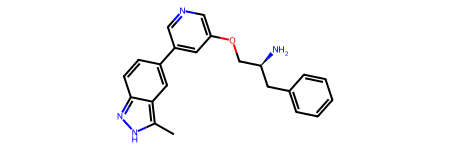

In [8]:
mol

In [9]:
ligand_id0

'L1'

In [10]:
os.makedirs(f"data/{data_name}/drug_mol", exist_ok=True)
for idx, row in ligand_pairs.iterrows():
    ligand_id = str(row['ligand_id'])
    writer = Chem.SDWriter(f"data/{data_name}/drug_mol/{ligand_id}.sdf")
    mol = Chem.MolFromSmiles(row['ligand'])
    if mol:
        writer.write(mol)
    writer.close()
    if idx > 5:
        break

In [11]:
cm = CheckMol()
res = cm.functionalGroups(file='data/Davis/drug_mol/L1.sdf', justFGcode=False,returnDataframe=True)

In [12]:
res

,Functional Group,Frequency,Atom Position,Functional Group Number,Code
0,ether,1,17,037,O1C00000
1,alkylarylether,1,17,039,O1C0CA00
2,amine,1,27,047,N1C00000
3,prim. amine,1,27,048,N1C10000
4,prim. aliphat. amine,1,27,049,N1C1C000
5,aromatic compound,4,"2-3-8-9-10-,3-4-5-6-7-8-,11-12-13-14-15-16-,21...",201,0000A000
6,heterocyclic compound,2,"2-3-8-9-10-,11-12-13-14-15-16-",202,0000CZ00


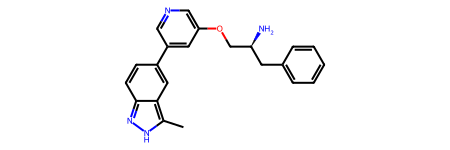

In [13]:
supplier = Chem.SDMolSupplier(f'data/{data_name}/drug_mol/L1.sdf')
supplier[0]

In [ ]:
len(glob("data/Davis/drug_mol/*.sdf"))

68

In [ ]:
df = pd.read_csv("data/Davis/Davis_preprocessed.csv")

In [17]:
print(len(set(df['protein_id'])))
print(len(set(df['ligand_id'])))

442
68


In [23]:
print(len(glob('data/Davis/drug_mol/*')))
print(len(glob('datapreprocessed/DavisFeature/fg_instance/*')))
print(len(glob('datapreprocessed/DavisFeature/ligand_graph/*')))
print(len(glob('datapreprocessed/DavisFeature/protein_embeddings/*')))

68
68
68
442


In [25]:
df = pd.read_csv('data/Davis/Davis_preprocessed.csv')
df.head()

,Unnamed: 0,ligand,protein,label,protein_matched,protein_seq,ligand_id,protein_id,split
0,0,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,AAK1,7.366532,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...,L1,P1,Train_4
1,1,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(E255K)-phosphorylated,5.000000,ABL1(E255K),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P2,Train_5
2,2,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(F317I)-nonphosphorylated,5.000000,ABL1(F317I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P3,Train_2
3,3,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(F317I)-phosphorylated,5.000000,ABL1(F317I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P4,Train_2
4,4,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(F317L)-nonphosphorylated,5.000000,ABL1(F317L)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P5,Train_5


In [26]:
df[df['split'] == 'Test']

,Unnamed: 0,ligand,protein,label,protein_matched,protein_seq,ligand_id,protein_id,split
19,19,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ACVR2A,5.000000,ACVR2A,MGAAAKLAFAVFLISCSSGAILGRSETQECLFFNANWEKDRTNQTG...,L1,P20,Test
21,21,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ACVRL1,5.000000,ACVRL1,MTLGSPRKGLLMLLMALVTQGDPVKPSRGPLVTCTCESPHCKGPTC...,L1,P22,Test
27,27,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ALK,5.000000,ALK,MGAIGLLWLLPLLLSTAAVGSGMGTGQRAGSPAAGPPLQPREPLSY...,L1,P28,Test
47,47,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,BRSK1,5.000000,BRSK1,MSSGAKEGGGGSPAYHLPHPHPHPPQHAQYVGPYRLEKTLGKGQTG...,L1,P48,Test
51,51,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,CAMK1D,5.619789,CAMK1D,MARENGESSSSWKKQAEDIKKIFEFKETLGTGAFSEVVLAEEKATG...,L1,P52,Test
...,...,...,...,...,...,...,...,...,...
30026,30026,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TLK2,5.000000,TLK2,MMEELHSLDPRRQELLEARFTGVGVSKGPLNSESSNQSLCSVGSLS...,L68,P413,Test
30027,30027,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TNIK,5.000000,TNIK,MASDSPARSLDEIDLSALRDPAGIFELVELVGNGTYGQVYKGRHVK...,L68,P414,Test
30031,30031,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TRKA,5.000000,TRKA,MLRGGRRGQLGWHSWAAGPGSLLAWLILASAGAAPCPDACCPHGSS...,L68,P418,Test
30049,30049,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,YANK2,5.000000,YANK2,MGGNHSHKPPVFDENEEVNFDHFQILRAIGKGSFGKVCIVQKRDTK...,L68,P436,Test


In [28]:
df[df['split'] == 'Train_1']

,Unnamed: 0,ligand,protein,label,protein_matched,protein_seq,ligand_id,protein_id,split
7,7,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(H396P)-phosphorylated,5.000000,ABL1(H396P)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P8,Train_1
8,8,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(M351T)-phosphorylated,5.000000,ABL1(M351T),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P9,Train_1
11,11,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL1(T315I)-nonphosphorylated,5.000000,ABL1(T315I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,L1,P12,Train_1
16,16,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,ABL2,5.000000,ABL2,MVLGTVLLPPNSYGRDQDTSLCCLCTEASESALPDLTDHFASCVED...,L1,P17,Train_1
24,24,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OC[C@H](CC4=C...,AKT1,7.119186,AKT1,MSDVAIVKEGWLHKRGEYIKTWRPRYFLLKNDGTFIGYKERPQDVD...,L1,P25,Train_1
...,...,...,...,...,...,...,...,...,...
30032,30032,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TRKB,5.000000,TRKB,MSSWIRWHGPAMARLWGFCWLVVGFWRAAFACPTSCKCSASRIWCS...,L68,P419,Train_1
30034,30034,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TRPM6,5.000000,TRPM6,MKEQPVLERLQSQKSWIKGVFDKRECSTIIPSSKNPHRCTPVCQVC...,L68,P421,Train_1
30040,30040,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,TYRO3,5.000000,TYRO3,MALRRSMGRPGLPPLPLPPPPRLGLLLAALASLLLPESAAAGLKLM...,L68,P427,Train_1
30044,30044,C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=...,VEGFR2,7.207608,VEGFR2,MQSKVLLAVALWLCVETRAASVGLPSVSLDLPRLSIQKDILTIKAN...,L68,P431,Train_1


In [32]:
with open(f"data/Davis/train_folds.txt", "r", encoding="utf-8") as f:
        content = f.read()

train_folds = ast.literal_eval(content)

In [33]:
sorted(train_folds[0])

[7,
 8,
 11,
 16,
 24,
 28,
 31,
 36,
 37,
 52,
 53,
 54,
 56,
 72,
 80,
 81,
 89,
 92,
 96,
 101,
 104,
 114,
 123,
 125,
 142,
 144,
 156,
 158,
 159,
 161,
 166,
 167,
 168,
 169,
 183,
 184,
 195,
 216,
 221,
 232,
 234,
 241,
 256,
 281,
 284,
 285,
 286,
 294,
 303,
 305,
 310,
 311,
 312,
 322,
 325,
 332,
 335,
 341,
 361,
 375,
 380,
 384,
 387,
 390,
 393,
 397,
 399,
 420,
 422,
 426,
 429,
 431,
 434,
 435,
 438,
 440,
 450,
 470,
 475,
 478,
 482,
 483,
 501,
 503,
 530,
 540,
 541,
 544,
 554,
 568,
 569,
 574,
 601,
 613,
 630,
 636,
 645,
 651,
 652,
 664,
 666,
 674,
 678,
 681,
 685,
 691,
 692,
 697,
 705,
 710,
 721,
 722,
 724,
 733,
 734,
 737,
 738,
 758,
 769,
 819,
 820,
 836,
 850,
 852,
 853,
 855,
 863,
 875,
 899,
 906,
 919,
 924,
 929,
 933,
 943,
 947,
 954,
 957,
 963,
 964,
 979,
 1008,
 1022,
 1029,
 1034,
 1039,
 1042,
 1043,
 1047,
 1066,
 1073,
 1089,
 1096,
 1101,
 1113,
 1117,
 1119,
 1140,
 1141,
 1146,
 1153,
 1167,
 1176,
 1179,
 1181,
 1188,


In [4]:
import numpy as np

ci_lst = [0.8895, 0.8955, 0.8921, 0.8982, 0.9003]

# Mean
mean = np.mean(ci_lst)

# Standard deviation
std = np.std(ci_lst)

print("Mean:", mean)
print("Std:", std)

Mean: 0.89512
Std: 0.003928562077910958


In [5]:
mse_lst = [(0.5848)**2, (0.5414)**2, (0.5765)**2, (0.5487)**2, (0.5420)**2]

# Mean
mean = np.mean(mse_lst)

# Standard deviation
std = np.std(mse_lst)

print("Mean:", mean)
print("Std:", std)

Mean: 0.312458588
Std: 0.02059751056760539


In [6]:
r_2_lst = [0.6382, 0.6880, 0.6711, 0.6928,0.6827]

# Mean
mean = np.mean(r_2_lst)

# Standard deviation
std = np.std(r_2_lst)

print("Mean:", mean)
print("Std:", std)

Mean: 0.67456
Std: 0.019563292156485307
